<a href="https://colab.research.google.com/github/RoJo1205/Maestr-a-Inteligencia-Artificial/blob/main/AlexNet_OxfordIIITPet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo CNN — AlexNet (adaptado)
## Oxford-IIIT Pet Dataset


Este notebook desarrolla **únicamente** el modelo CNN basado en la arquitectura **AlexNet**.

Clasificador de razas de perros y gatos con accuracy ≥ 85% en **test**, sin evidencias de overfitting ni underfitting.


## 0. Librerías

In [4]:
import numpy as np
import time
import json
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import tensorflow_datasets as tfds

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Reinstall tensorflow and tensorflow-datasets to resolve Protobuf version conflicts
# This ensures all dependencies are compatible.
!pip install --upgrade tensorflow tensorflow-datasets


TensorFlow: 2.21.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Carga del dataset

Carga indicada en el notebook: 80% train / 10% validation / 10% test, usando `tfds.load` sobre `oxford_iiit_pet`.

In [5]:
# Install importlib_resources
!pip install importlib_resources

split_data, info = tfds.load(
    'oxford_iiit_pet',
    split=[
        'train[:80%]',     # entrenamiento
        'train[80%:90%]',  # validación
        'train[90%:]'],    # prueba
    with_info=True,
    as_supervised=True
)

(train_ds_raw, val_ds_raw, test_ds_raw) = split_data

IMG_SIZE = 160  # tamaño de entrada definido en el notebook


## 2. Análisis exploratorio del dataset

Antes de construir AlexNet, se analiza el dataset para comprender su estructura, sus clases y su distribución.

In [6]:
num_classes = info.features['label'].num_classes
class_names = info.features['label'].names

n_train = info.splits['train'].num_examples

print(f"Número de clases (razas): {num_classes}")
print(f"Ejemplos totales en 'train' (fuente de los 3 splits): {n_train}")
print(f"Clases: {class_names}")
print()
print(f"Ejemplos en TRAIN (80%): {tf.data.experimental.cardinality(train_ds_raw).numpy()}")
print(f"Ejemplos en VALIDATION (10%): {tf.data.experimental.cardinality(val_ds_raw).numpy()}")
print(f"Ejemplos en TEST (10%): {tf.data.experimental.cardinality(test_ds_raw).numpy()}")


Número de clases (razas): 37
Ejemplos totales en 'train' (fuente de los 3 splits): 3680
Clases: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

Ejemplos en TRAIN (80%): 2944
Ejemplos en VALIDATION (10%): 368
Ejemplos en TEST (10%): 368


In [7]:
# Estructura de un elemento del dataset
for image, label in train_ds_raw.take(1):
    print("Shape de la imagen:", image.shape)
    print("Dtype de la imagen:", image.dtype)
    print("Label (entero):", label.numpy(), "->", class_names[label.numpy()])


Shape de la imagen: (500, 500, 3)
Dtype de la imagen: <dtype: 'uint8'>
Label (entero): 33 -> Sphynx


### 2.1 Visualización de ejemplos representativos

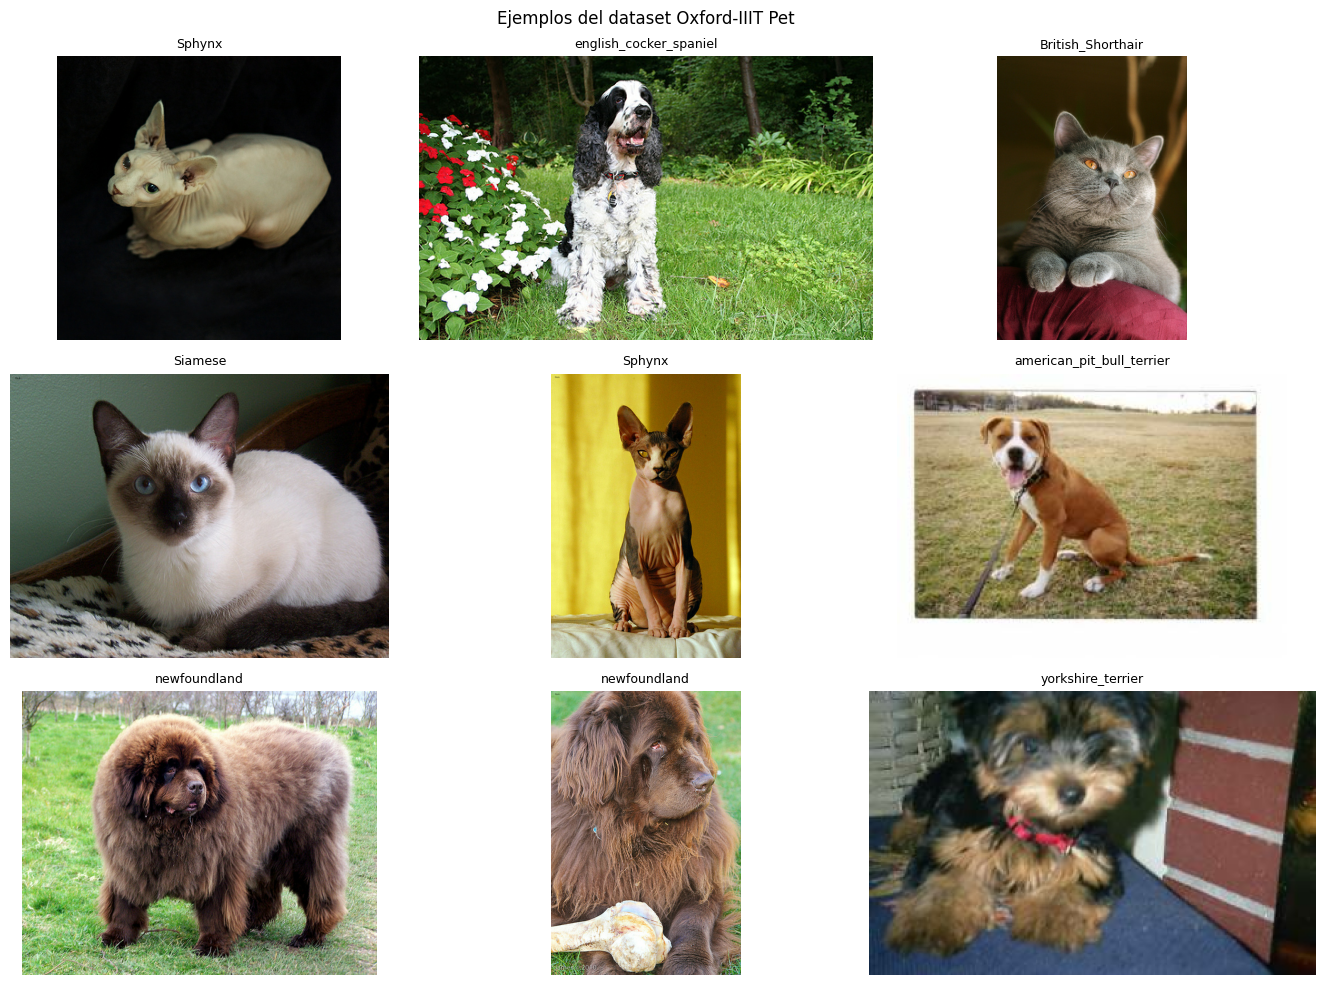

In [8]:
plt.figure(figsize=(14, 10))
for i, (image, label) in enumerate(train_ds_raw.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(class_names[label.numpy()], fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos del dataset Oxford-IIIT Pet")
plt.tight_layout()
plt.show()


### 2.2 Distribución de clases

Se cuenta el número de ejemplos por clase en el split de entrenamiento para detectar posibles desbalances.

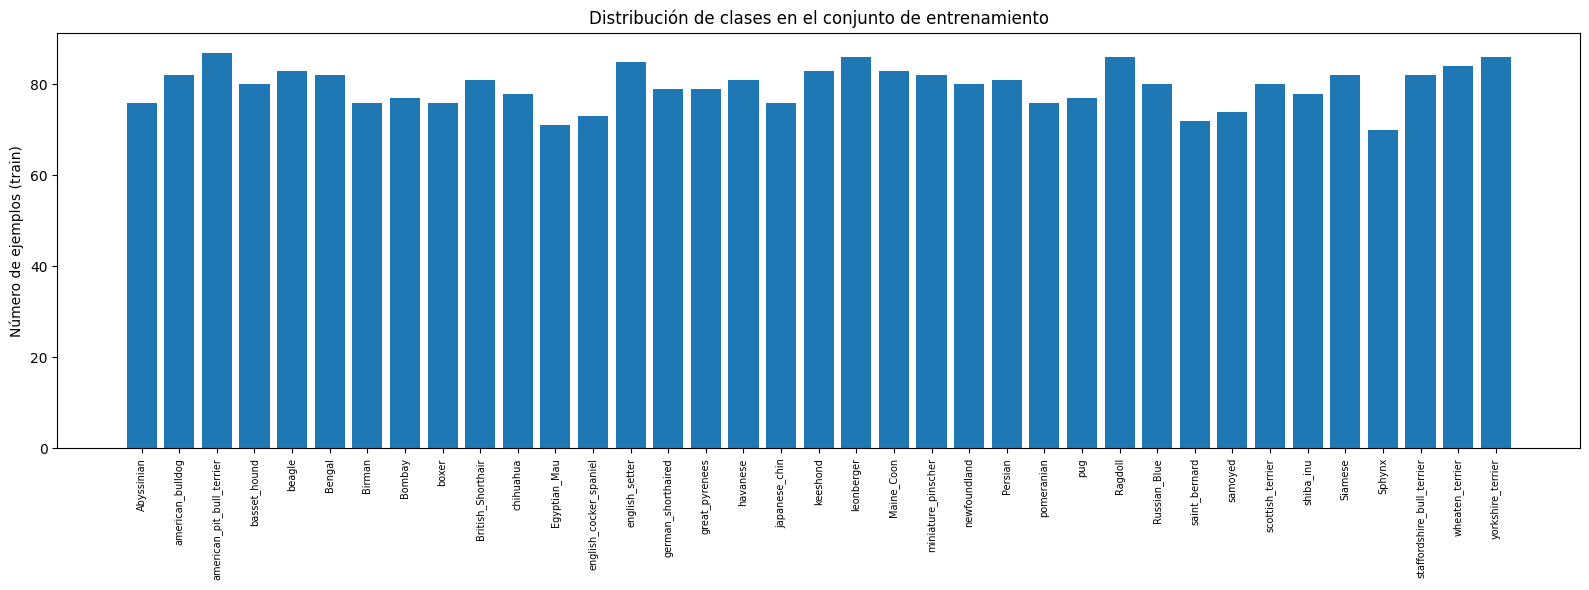

Mínimo de ejemplos por clase: 70
Máximo de ejemplos por clase: 87
Promedio de ejemplos por clase: 79.6
Desviación estándar: 4.3


In [9]:
labels_train = np.array([label.numpy() for _, label in train_ds_raw])
counts = np.bincount(labels_train, minlength=num_classes)

plt.figure(figsize=(16, 6))
plt.bar(range(num_classes), counts)
plt.xticks(range(num_classes), class_names, rotation=90, fontsize=7)
plt.ylabel("Número de ejemplos (train)")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.tight_layout()
plt.show()

print(f"Mínimo de ejemplos por clase: {counts.min()}")
print(f"Máximo de ejemplos por clase: {counts.max()}")
print(f"Promedio de ejemplos por clase: {counts.mean():.1f}")
print(f"Desviación estándar: {counts.std():.1f}")


**Observación:** el dataset presenta un número relativamente balanceado de ejemplos por raza (Oxford-IIIT Pet tiene ~200 imágenes por clase en el conjunto completo), aunque el split aleatorio 80/10/10 puede introducir ligeras variaciones. No se observa un desbalance severo que requiera técnicas específicas de balanceo (p. ej. class weights), aunque se deja como punto de atención en el análisis de errores por clase.

## 3. Pipeline `tf.data`

Se construye un pipeline eficiente:

```
Dataset -> Resize -> Normalize -> Data Augmentation (solo TRAIN) -> Batch -> Prefetch
```

La normalización (`/255.0`) se aplica igual a los tres splits. El data augmentation se aplica **únicamente** al split de entrenamiento.

In [10]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def resize_and_normalize(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Capa de augmentation (Keras preprocessing layers)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

def build_pipeline(ds, augment_data=False, shuffle=False, batch_size=BATCH_SIZE):
    ds = ds.map(resize_and_normalize, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Validación y test: SIN augmentation
val_ds = build_pipeline(val_ds_raw, augment_data=False, shuffle=False)
test_ds = build_pipeline(test_ds_raw, augment_data=False, shuffle=False)

# Dos versiones de entrenamiento, para el experimento con y sin augmentation (sección 6)
train_ds_noaug = build_pipeline(train_ds_raw, augment_data=False, shuffle=True)
train_ds_aug   = build_pipeline(train_ds_raw, augment_data=True,  shuffle=True)


## 4. Arquitectura AlexNet (adaptada)

Se implementa AlexNet **desde cero** (sin `keras.applications`), conservando su filosofía original:

```
Input -> Conv -> ReLU -> Pool -> Conv -> ReLU -> Conv -> ReLU -> Conv -> ReLU -> Conv -> ReLU -> Pool
      -> Flatten -> FC -> Dropout -> FC -> Dropout -> Output(Softmax)
```

**Adaptaciones respecto a la AlexNet original (diseñada para 224×224 e ImageNet-1000):**
- Entrada 160×160×3 en lugar de 224×224×3 → se reduce el kernel y el stride de la primera convolución (11×11/stride 4 sobrevivía en 224 pero deja muy poca resolución en 160), usando 7×7/stride 2 para conservar más información espacial temprana.
- Número de filtros reducido en las primeras capas (dataset mucho más pequeño que ImageNet: ~7,000 imágenes vs 1.2M) para reducir el riesgo de overfitting y el costo computacional.
- Capas Dense reducidas de 4096→4096 a 512→256, ya que 4096 neuronas son excesivas para ~37 clases y un dataset de este tamaño (demasiados parámetros -> overfitting).
- Se añade `BatchNormalization` tras las convoluciones para estabilizar y acelerar el entrenamiento (no estaba en la AlexNet original, que usaba LRN, hoy en desuso).
- Se añade `l2` opcional y `Dropout` en las capas densas para controlar el overfitting.
- La capa de salida tiene `num_classes` neuronas con activación `softmax` (obtenido de `info`, sin hardcodear).

In [11]:
def build_alexnet(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                   num_classes=num_classes,
                   dense_units=(512, 256),
                   dropout_rate=0.5,
                   l2_reg=1e-4,
                   learning_rate=1e-3):
    """Construye y compila una CNN basada en AlexNet, adaptada a 160x160x3
    y al número de clases del dataset Oxford-IIIT Pet.

    Parámetros
    ----------
    input_shape : tuple  - forma de entrada (alto, ancho, canales)
    num_classes : int    - número de clases de salida (obtenido de info, no hardcodeado)
    dense_units : tuple  - tamaño de las dos capas Fully Connected internas
    dropout_rate: float  - tasa de dropout tras cada capa densa interna
    l2_reg      : float  - factor de regularización L2 en capas densas
    learning_rate: float - learning rate del optimizador Adam
    """
    reg = regularizers.l2(l2_reg) if l2_reg else None

    model = models.Sequential(name="AlexNet_adaptado", layers=[
        layers.Input(shape=input_shape),

        # Bloque 1: Conv -> ReLU -> Pool
        layers.Conv2D(48, kernel_size=7, strides=2, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2, padding="same"),

        # Bloque 2: Conv -> ReLU -> Pool
        layers.Conv2D(128, kernel_size=5, strides=1, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2, padding="same"),

        # Bloque 3-5: tres convoluciones consecutivas
        layers.Conv2D(192, kernel_size=3, strides=1, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(192, kernel_size=3, strides=1, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, kernel_size=3, strides=1, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=3, strides=2, padding="same"),

        # Flatten + Fully Connected
        layers.Flatten(),
        layers.Dense(dense_units[0], activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units[1], activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout_rate),

        # Salida
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),  # etiquetas como enteros
        metrics=["accuracy"],
    )
    return model

build_alexnet().summary()


Model: "AlexNet_adaptado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 48)     │         7,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │       153,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 192)    │       221,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 192)    │       331,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,633,189 (29.12 MB)

 Trainable params: 7,631,813 (29.11 MB)

 Non-trainable params: 1,376 (5.38 KB)

## 5. Callbacks de entrenamiento

- **EarlyStopping**: detiene el entrenamiento si `val_loss` no mejora, evitando overfitting y tiempo de cómputo innecesario. Restaura los mejores pesos.
- **ReduceLROnPlateau**: reduce el learning rate cuando `val_loss` se estanca.
- **ModelCheckpoint**: guarda el mejor modelo según `val_accuracy` (selección basada en VALIDATION, nunca en TEST).

In [12]:
def make_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True, save_weights_only=False),
    ]

EPOCHS = 40
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)


## 6. Experimento: Configuración A (sin augmentation) vs Configuración B (con augmentation)

Ambas configuraciones usan la **misma arquitectura AlexNet** y se entrenan/seleccionan usando **solo TRAIN y VALIDATION**. El conjunto TEST se reserva por completo para la evaluación final (sección 7), sobre la configuración ganadora.

### 6.1 Configuración A — AlexNet + normalización, SIN data augmentation

In [13]:
model_A = build_alexnet()

start = time.time()
history_A = model_A.fit(
    train_ds_noaug,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks("checkpoints/alexnet_config_A.keras"),
    verbose=1
)
time_A = time.time() - start
print(f"Tiempo de entrenamiento Config A: {time_A/60:.1f} min")


Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - accuracy: 0.0312 - loss: 6.2539 - val_accuracy: 0.0217 - val_loss: 3.7732 - learning_rate: 0.0010
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.0255 - loss: 3.7934 - val_accuracy: 0.0190 - val_loss: 3.7653 - learning_rate: 0.0010
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.0279 - loss: 3.7715 - val_accuracy: 0.0136 - val_loss: 3.7652 - learning_rate: 0.0010
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.0309 - loss: 3.7621 - val_accuracy: 0.0163 - val_loss: 3.7876 - learning_rate: 0.0010
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.0262 - loss: 3.8045 - val_accuracy: 0.0299 - val_loss: 3.7784 - learning_rate: 0.0010
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.0309 - loss: 3.7786 - val_accuracy: 0.0217 - val_loss: 3.7633 - learning_rate: 0.0010
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.0299 - loss: 3.7950 - va

### 6.2 Configuración B — AlexNet + normalización, CON data augmentation

In [14]:
model_B = build_alexnet()

start = time.time()
history_B = model_B.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks("checkpoints/alexnet_config_B.keras"),
    verbose=1
)
time_B = time.time() - start
print(f"Tiempo de entrenamiento Config B: {time_B/60:.1f} min")


Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 276ms/step - accuracy: 0.0346 - loss: 6.5353 - val_accuracy: 0.0272 - val_loss: 3.8138 - learning_rate: 0.0010
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.0309 - loss: 4.0737 - val_accuracy: 0.0380 - val_loss: 3.7572 - learning_rate: 0.0010
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.0346 - loss: 3.8378 - val_accuracy: 0.0353 - val_loss: 3.7809 - learning_rate: 0.0010
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 275ms/step - accuracy: 0.0323 - loss: 3.7730 - val_accuracy: 0.0543 - val_loss: 3.7050 - learning_rate: 0.0010
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 259ms/step - accuracy: 0.0411 - loss: 3.7360 - val_accuracy: 0.0408 - val_loss: 3.6994 - learning_rate: 0.0010
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.0414 - loss: 3.7299 - val_accuracy: 0.0353 - val_loss: 3.7097 - learning_rate: 0.0010
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.0408 - loss: 3.

### 6.3 Curvas de entrenamiento (diagnóstico de overfitting / underfitting)

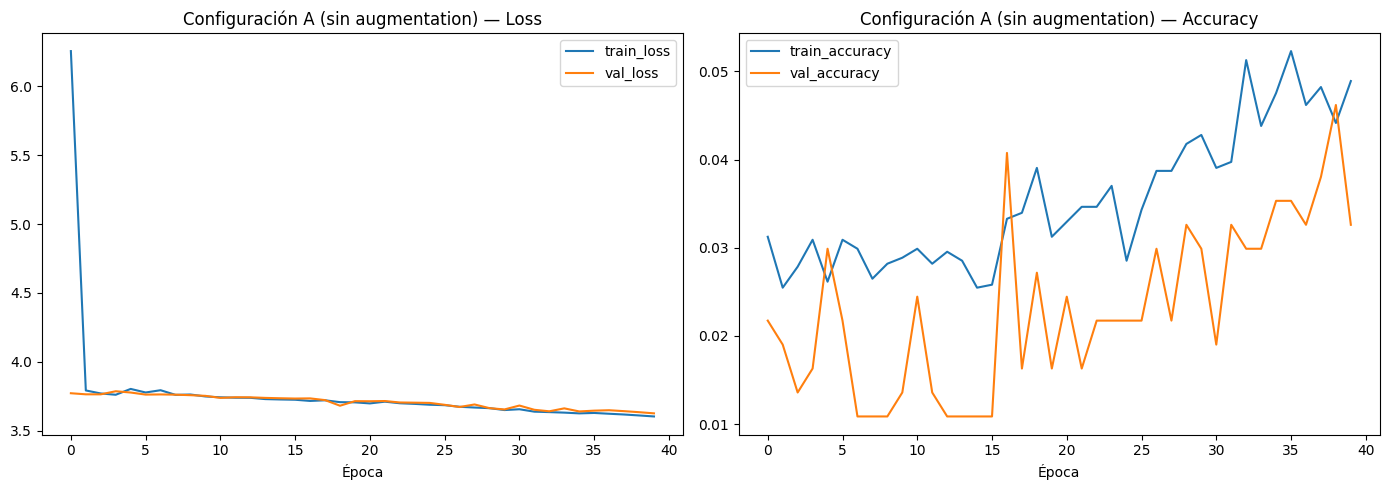

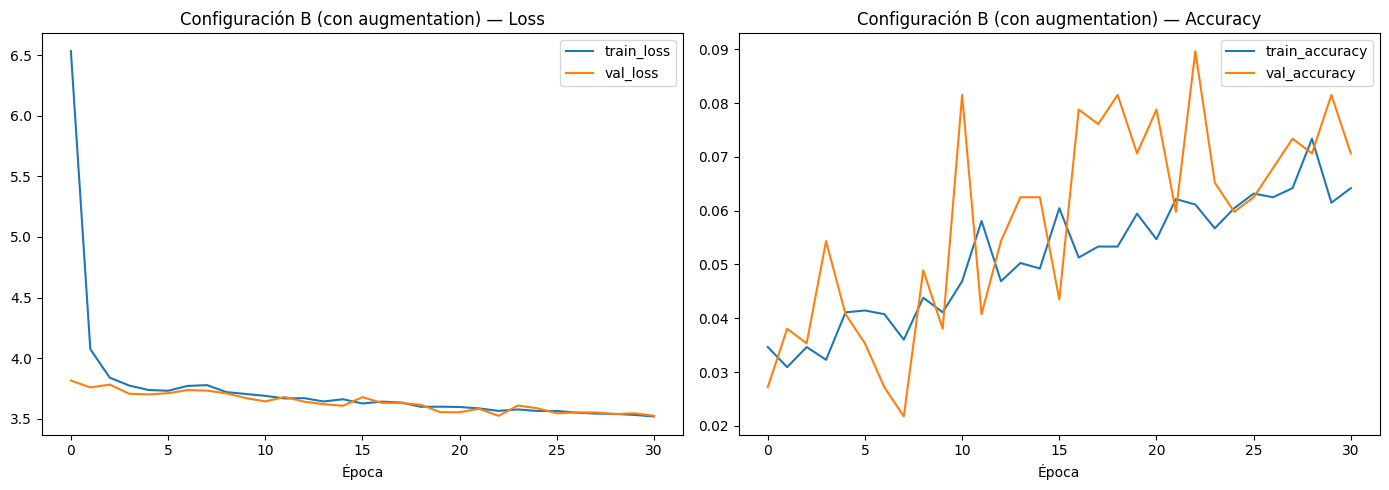

In [15]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["loss"], label="train_loss")
    axes[0].plot(history.history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train_accuracy")
    axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_A, "Configuración A (sin augmentation)")
plot_history(history_B, "Configuración B (con augmentation)")


**Cómo interpretar estas curvas (a completar tras la ejecución real):**
- **Underfitting**: `train_loss` y `val_loss` altos y estancados desde épocas tempranas, accuracy baja en ambos conjuntos → indicaría que el modelo necesita más capacidad o más épocas.
- **Overfitting**: `train_loss` sigue bajando mientras `val_loss` sube (o se separa claramente de `train_loss`), `train_accuracy` mucho mayor que `val_accuracy` → indicaría reforzar regularización (más dropout, más augmentation, más weight decay) o reducir capacidad.
- **Ajuste adecuado**: `train` y `val` evolucionan de forma similar, ambas curvas de loss convergen y las de accuracy se estabilizan cerca la una de la otra.

## 7. Comparación A vs B y selección del mejor modelo (basada en VALIDATION)

La selección de la configuración ganadora se realiza exclusivamente con las métricas de `val_accuracy` / `val_loss`. El conjunto de test **no interviene** en esta decisión.

In [16]:
best_val_acc_A = max(history_A.history["val_accuracy"])
best_val_acc_B = max(history_B.history["val_accuracy"])
best_val_loss_A = min(history_A.history["val_loss"])
best_val_loss_B = min(history_B.history["val_loss"])

print("Configuración A (sin augmentation):")
print(f"  Mejor val_accuracy: {best_val_acc_A:.4f}")
print(f"  Mejor val_loss:     {best_val_loss_A:.4f}")
print()
print("Configuración B (con augmentation):")
print(f"  Mejor val_accuracy: {best_val_acc_B:.4f}")
print(f"  Mejor val_loss:     {best_val_loss_B:.4f}")

if best_val_acc_B >= best_val_acc_A:
    best_config = "B"
    best_model = keras.models.load_model("checkpoints/alexnet_config_B.keras")
else:
    best_config = "A"
    best_model = keras.models.load_model("checkpoints/alexnet_config_A.keras")

print(f"\nConfiguración seleccionada (según VALIDATION): {best_config}")


Configuración A (sin augmentation):
  Mejor val_accuracy: 0.0462
  Mejor val_loss:     3.6273

Configuración B (con augmentation):
  Mejor val_accuracy: 0.0897
  Mejor val_loss:     3.5222

Configuración seleccionada (según VALIDATION): B


## 8. Evaluación FINAL sobre TEST

Esta es la **única vez** que el conjunto `test_ds` se utiliza en todo el desarrollo, y se aplica exclusivamente sobre la configuración ya seleccionada con validación.

In [17]:
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)
print(f"\nAccuracy final en TEST: {test_accuracy:.4f}")
print(f"Loss final en TEST: {test_loss:.4f}")
print(f"¿Cumple el umbral de 85% de accuracy en test?: {'SÍ' if test_accuracy >= 0.85 else 'NO'}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.0571 - loss: 3.5272

Accuracy final en TEST: 0.0571
Loss final en TEST: 3.5272
¿Cumple el umbral de 85% de accuracy en test?: NO


### 8.1 Precision, recall y matriz de confusión por clase

In [18]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step
                            precision    recall  f1-score   support

                Abyssinian       0.00      0.00      0.00        12
          american_bulldog       0.00      0.00      0.00        12
 american_pit_bull_terrier       0.00      0.00      0.00         8
              basset_hound       0.00      0.00      0.00        12
                    beagle       0.00      0.00      0.00         9
                    Bengal       0.00      0.00      0.00         8
                    Birman       0.00      0.00      0.00        16
                    Bombay       0.29      0.64      0.40        11
                     boxer       0.00      0.00      0.00        10
         British_Shorthair       0.00      0.00      0.00        12
                 chihuahua       0.00      0.00      0.00        10
              Egyptian_Mau       0.00      0.00      0.00        11
    english_cocker_spaniel       0.00      0.00      0.00        10
      

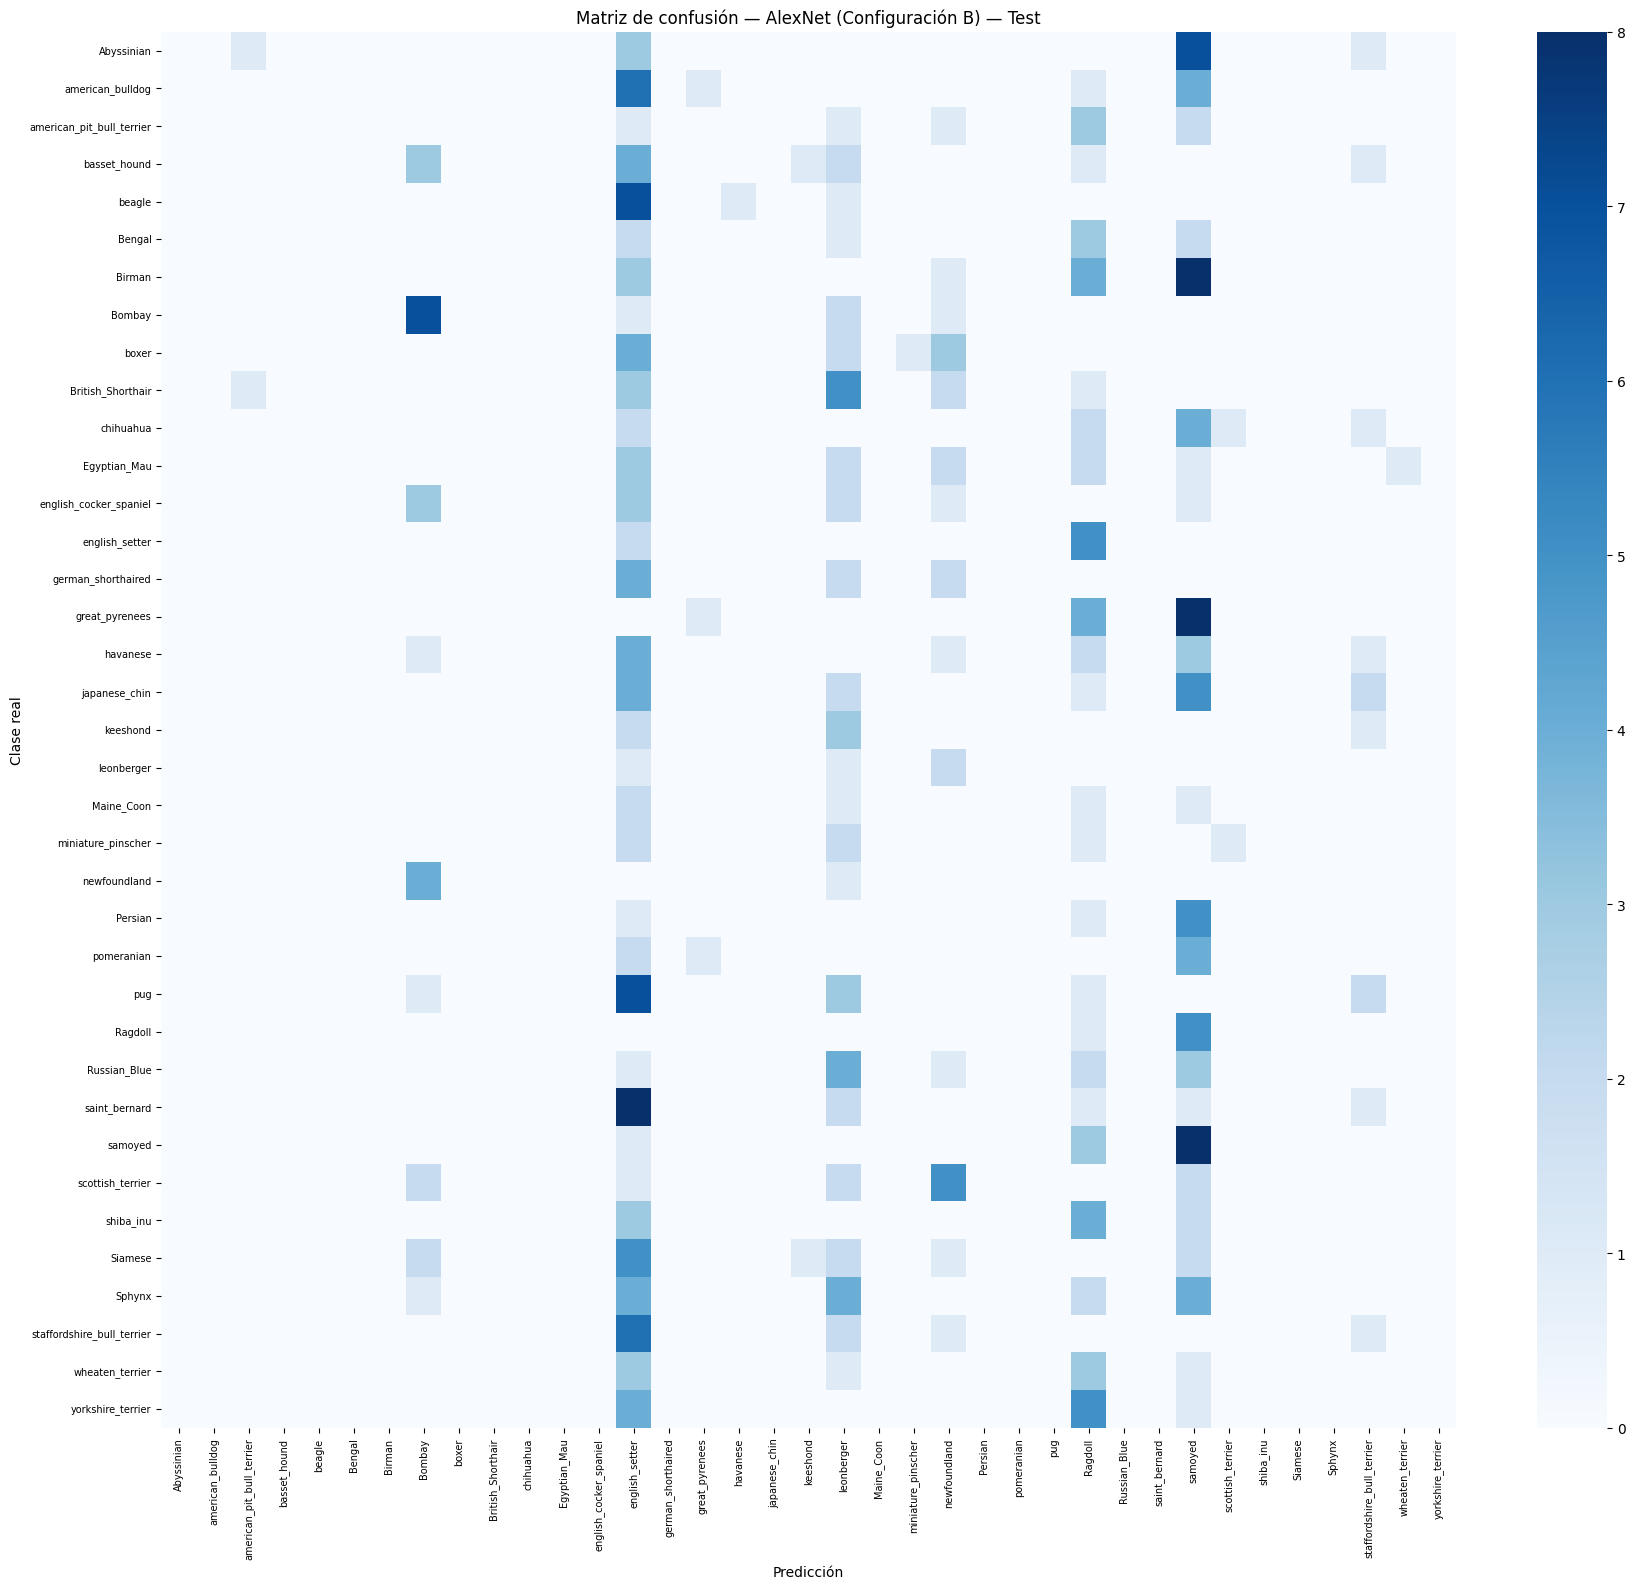

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues", cbar=True)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title(f"Matriz de confusión — AlexNet (Configuración {best_config}) — Test")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


### 8.2 Análisis visual de errores

Se muestran ejemplos mal clasificados para identificar qué razas generan mayor confusión.

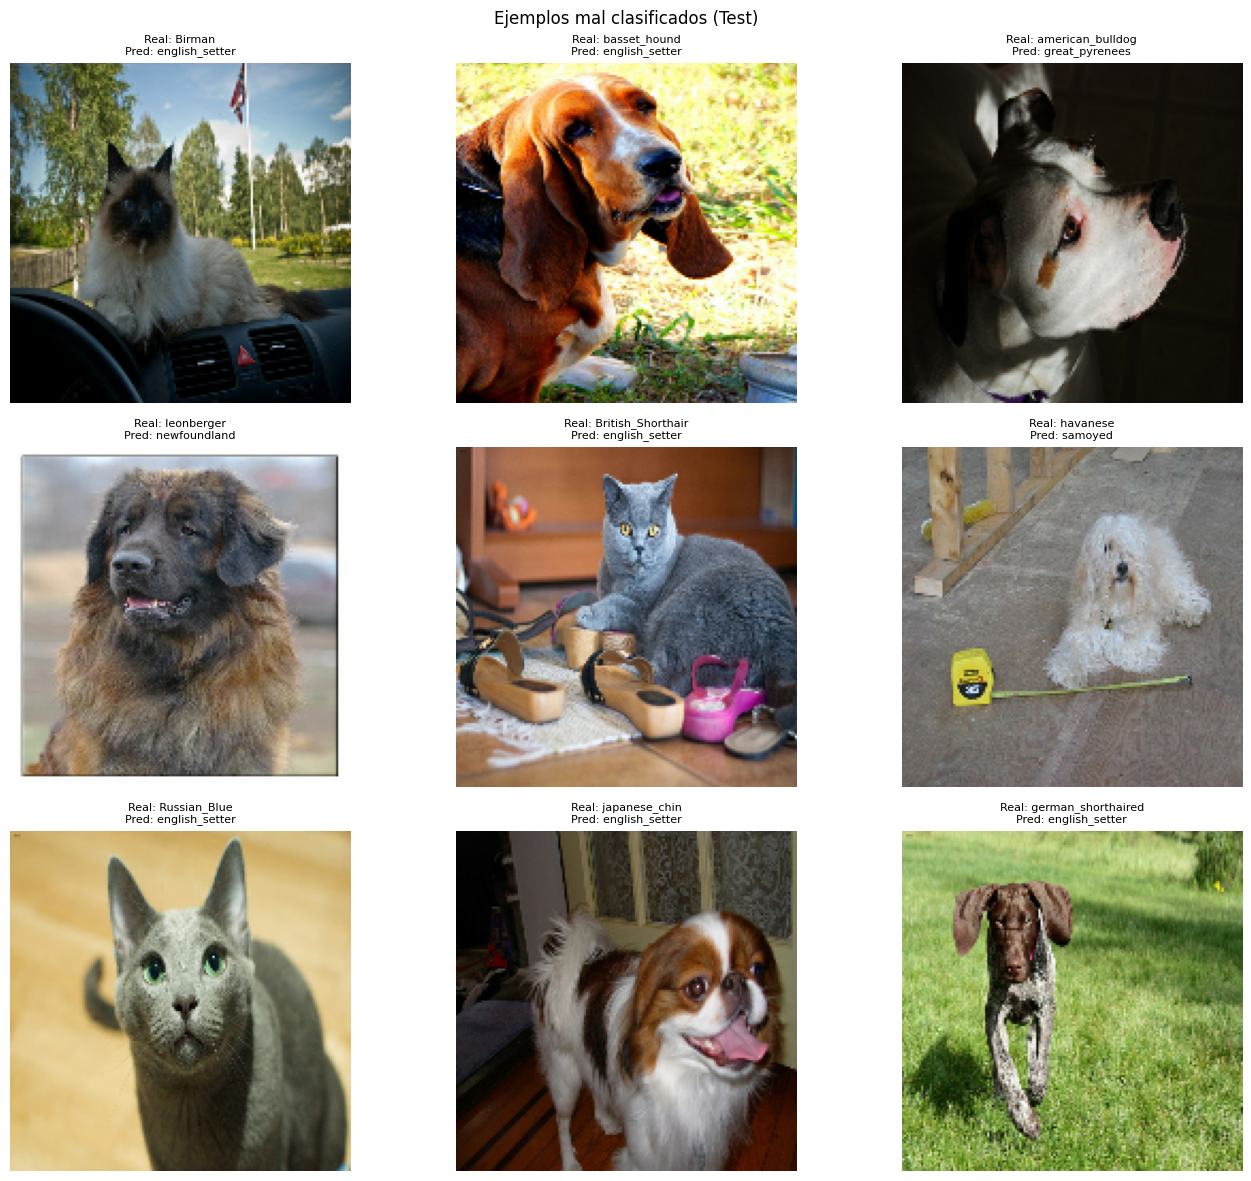

Total de errores en test: 347 de 368 (94.3%)


In [20]:
images_test = np.concatenate([x.numpy() for x, _ in test_ds])
wrong_idx = np.where(y_pred != y_true)[0]

n_show = min(9, len(wrong_idx))
plt.figure(figsize=(14, 12))
for i, idx in enumerate(wrong_idx[:n_show]):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_test[idx])
    plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Ejemplos mal clasificados (Test)")
plt.tight_layout()
plt.show()

print(f"Total de errores en test: {len(wrong_idx)} de {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")


## 9. Diagnóstico final de overfitting / underfitting

Comparación entre el desempeño en train, validation y test de la configuración seleccionada.

In [21]:
final_train_acc = history_A.history["accuracy"][-1] if best_config == "A" else history_B.history["accuracy"][-1]
final_val_acc = best_val_acc_A if best_config == "A" else best_val_acc_B

print(f"Accuracy final TRAIN:      {final_train_acc:.4f}")
print(f"Mejor accuracy VALIDATION: {final_val_acc:.4f}")
print(f"Accuracy final TEST:       {test_accuracy:.4f}")

gap_train_val = final_train_acc - final_val_acc
print(f"\nBrecha train-val: {gap_train_val:.4f}")
if gap_train_val > 0.15:
    print("-> Posible overfitting: revisar dropout/regularización/augmentation.")
elif final_val_acc < 0.6:
    print("-> Posible underfitting: revisar capacidad del modelo o número de épocas.")
else:
    print("-> No hay evidencia clara de overfitting ni underfitting severos.")


Accuracy final TRAIN:      0.0642
Mejor accuracy VALIDATION: 0.0897
Accuracy final TEST:       0.0571

Brecha train-val: -0.0255
-> Posible underfitting: revisar capacidad del modelo o número de épocas.


## 10. Guardado de artefactos para la comparación grupal

Se guardan el modelo, el historial de entrenamiento y las métricas finales.

In [22]:
results_summary = {
    "model_name": "AlexNet_adaptado",
    "config_seleccionada": best_config,
    "img_size": IMG_SIZE,
    "num_classes": num_classes,
    "train_accuracy_final": float(final_train_acc),
    "val_accuracy_best": float(final_val_acc),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "cumple_umbral_85": bool(test_accuracy >= 0.85),
    "tiempo_entrenamiento_A_min": time_A / 60,
    "tiempo_entrenamiento_B_min": time_B / 60,
}

with open("results/alexnet_results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

with open("results/alexnet_history_A.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_A.history.items()}, f, indent=2)

with open("results/alexnet_history_B.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_B.history.items()}, f, indent=2)

best_model.save("results/alexnet_best_model.keras")

print("Artefactos guardados en la carpeta 'results/':")
print(os.listdir("results"))


Artefactos guardados en la carpeta 'results/':
['alexnet_history_A.json', 'alexnet_results_summary.json', 'alexnet_best_model.keras', 'alexnet_history_B.json']
